# Clase 02: Listas, conjuntos, diccionarios y eficiencia

Pregunta guía:

> ¿Cómo podemos observar que una estructura de datos es mejor que otra para cierta operación?

Idea central:

> No existe una estructura de datos mejor en absoluto. Existe una estructura más adecuada para ciertas operaciones.

## Objetivos

Al terminar este notebook podrás:

- Medir tiempos de ejecución en Python.
- Comparar búsqueda en `list` y `set`.
- Usar `dict` para contar frecuencias.
- Usar `collections.Counter`.
- Entender informalmente `O(1)`, `O(n)` y `O(n²)`.
- Explicar qué operación quieres hacer eficiente al elegir una estructura de datos.

## 1. Preparación

Esta celda carga el módulo auxiliar de la clase. Funciona si abres el notebook desde `clase_02/` o desde la carpeta principal del repositorio.

In [1]:
from pathlib import Path
import sys
import time
from collections import Counter

import matplotlib.pyplot as plt

candidatos = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'clase_02']
raiz = next(
    candidato for candidato in candidatos
    if (candidato / 'src' / 'mediciones.py').exists()
)

if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.mediciones import (
    buscar_en_conjunto,
    buscar_en_lista,
    comparar_busquedas_por_tamano,
    contar_con_counter,
    contar_con_diccionario,
    generar_datos,
    medir_tiempo,
)

print(f'Material cargado desde: {raiz}')

Material cargado desde: c:\Users\0255295\Documents\GitHub\EstructurasDatos\clase_02


## 2. Una primera medición con `time.perf_counter`

`time.perf_counter` permite medir intervalos cortos de tiempo. La idea básica es tomar una marca antes, ejecutar la operación y tomar otra marca después.

In [55]:
datos_pequenos = generar_datos(20)
objetivo = -1

inicio = time.perf_counter()
resultado = objetivo in datos_pequenos
fin = time.perf_counter()

print(f'Datos: {datos_pequenos}')
print(f'¿Aparece {objetivo}? {resultado}')
print(f'Tiempo medido: {fin - inicio:.10f} segundos')

Datos: [1, 0, 4, 3, 3, 2, 1, 8, 1, 9, 6, 0, 0, 1, 3, 3, 8, 9, 0, 8]
¿Aparece -1? False
Tiempo medido: 0.0000503000 segundos


### Pregunta

¿Por qué una medición tan pequeña puede variar si ejecutas la celda varias veces?

por el "ruido" o las operaciones o procesos que la computadora hace en paralelo a la medicion 

## 3. Función `medir_tiempo`

Usaremos una función que ejecuta varias veces una operación y regresa el tiempo promedio. Esta es la versión base que también aparece en la presentación.

In [45]:
def medir_tiempo_base(funcion, repeticiones=10):
    tiempos = []

    for _ in range(repeticiones):
        inicio = time.perf_counter()
        funcion()
        fin = time.perf_counter()
        tiempos.append(fin - inicio)

    return sum(tiempos) / len(tiempos)


tiempo = medir_tiempo_base(lambda: objetivo in datos_pequenos, repeticiones=10)
print(f'Tiempo promedio: {tiempo:.10f} segundos')

Tiempo promedio: 0.0000003100 segundos


## 4. Búsqueda en `list`

Una lista mantiene orden y repeticiones. Para saber si un valor aparece, Python puede tener que revisar muchos elementos.

In [62]:
n = 100_000
datos = generar_datos(n)
objetivo_presente = datos[-1]
objetivo_ausente = -1

tiempo_lista_presente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_presente),
    repeticiones=10,
)
tiempo_lista_ausente = medir_tiempo(
    lambda: buscar_en_lista(datos, objetivo_ausente),
    repeticiones=10,
)

print(f'Lista con {n:,} elementos')
print(f'Objetivo presente: {tiempo_lista_presente:.8f} segundos')
print(f'Objetivo ausente:  {tiempo_lista_ausente:.8f} segundos')

Lista con 100,000 elementos
Objetivo presente: 0.00003089 segundos
Objetivo ausente:  0.00060025 segundos


### Pregunta

Cuando el objetivo está ausente, ¿qué tiene que ocurrir antes de que Python pueda responder `False`?

- Debe de revisar toda la lista para corroborar que -1 no esta

## 5. Búsqueda en `set`

Un conjunto está diseñado para pertenencia. El costo promedio de preguntar `x in conjunto` suele comportarse como aproximadamente constante respecto al tamaño.

In [63]:
conjunto = set(datos)

tiempo_set_presente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_presente),
    repeticiones=10,
)
tiempo_set_ausente = medir_tiempo(
    lambda: buscar_en_conjunto(conjunto, objetivo_ausente),
    repeticiones=10,
)

print(f'Tamaño de la lista:    {len(datos):,}')
print(f'Tamaño del conjunto: {len(conjunto):,}')
print(f'Set, objetivo presente: {tiempo_set_presente:.10f} segundos')
print(f'Set, objetivo ausente:  {tiempo_set_ausente:.10f} segundos')

Tamaño de la lista:    100,000
Tamaño del conjunto: 10,000
Set, objetivo presente: 0.0000005300 segundos
Set, objetivo ausente:  0.0000002200 segundos


### Preguntas

1. ¿Por qué el conjunto puede tener menos elementos que la lista?

    - Porque no admite repeticiones  

2. ¿Qué sacrificios tiene usar un `set` si la lista original tenía orden y duplicados?

    - Se pierde informacion sobre posicion (indices) y frecuencia (cuantas veces aparece un mismo dato)

3. ¿Para qué operación parece más adecuado el conjunto?

    - Para buscar pertenencia

## 6. Comparar varios tamaños

Ahora compararemos búsqueda de un valor ausente con varios tamaños de entrada. El objetivo ausente ayuda a observar el costo de revisar toda la lista.

In [64]:
tamanos = [1_000, 5_000, 10_000, 50_000, 100_000, 200_000]
resultados = comparar_busquedas_por_tamano(tamanos, repeticiones=8)

print('tamaño      lista (s)       set (s)')
for fila in resultados:
    print(f"{fila['tamano']:>7,}   {fila['tiempo_lista']:>11.8f}   {fila['tiempo_conjunto']:>11.8f}")

tamaño      lista (s)       set (s)
  1,000    0.00000394    0.00000017
  5,000    0.00004346    0.00000013
 10,000    0.00006199    0.00000015
 50,000    0.00026772    0.00000028
100,000    0.00043171    0.00000026
200,000    0.00084709    0.00000029


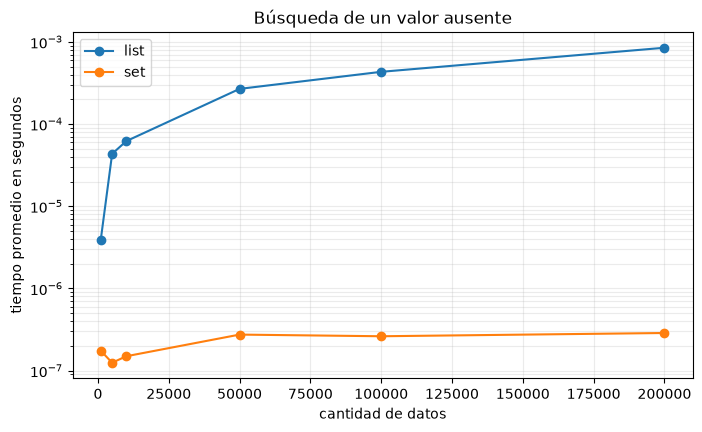

In [80]:
xs = [fila['tamano'] for fila in resultados]
ys_lista = [fila['tiempo_lista'] for fila in resultados]
ys_set = [fila['tiempo_conjunto'] for fila in resultados]

plt.figure(figsize=(8, 4.5))
plt.plot(xs, ys_lista, marker='o', label='list')
plt.plot(xs, ys_set, marker='o', label='set')
plt.yscale('log')
plt.xlabel('cantidad de datos')
plt.ylabel('tiempo promedio en segundos')
plt.title('Búsqueda de un valor ausente')
plt.grid(True, which='both', alpha=0.25)
plt.legend()
plt.show()

### Interpretación

Responde:

1. ¿Cuál fue más rápido?
    - El conjunto 
2. ¿La diferencia crece con el tamaño?
    - Si, mucho 
3. ¿Qué estructura usarías si necesitas muchas búsquedas?
    - Conjuntos
4. ¿Contamos aquí el costo de construir el conjunto? ¿Por qué importa esa pregunta?
    - Porque es un costo que debemos contmeplar pues forma parte del proceso completo de la usqueda 

## 7. Conteo con diccionario

Para contar frecuencias, una representación natural es:

$$\text{valor} \mapsto \text{frecuencia}$$

In [66]:
conteos_dict = contar_con_diccionario(datos)

print(f'Valores distintos: {len(conteos_dict):,}')
print('Primeros 8 pares valor -> frecuencia:')
for valor, frecuencia in list(conteos_dict.items())[:8]:
    print(f'{valor:>5} -> {frecuencia}')

Valores distintos: 10,000
Primeros 8 pares valor -> frecuencia:
 1824 -> 8
  409 -> 8
 4506 -> 14
 4012 -> 9
 3657 -> 15
 2286 -> 15
 1679 -> 8
 8935 -> 4


## 8. Conteo con `Counter`

`Counter` es una herramienta especializada de Python para contar ocurrencias.

In [67]:
conteos_counter = contar_con_counter(datos)

print('Los 8 valores más frecuentes:')
for valor, frecuencia in conteos_counter.most_common(8):
    print(f'{valor:>5} -> {frecuencia}')

assert dict(conteos_counter) == conteos_dict
print('El diccionario y Counter representan las mismas frecuencias.')

Los 8 valores más frecuentes:
 7289 -> 24
 7779 -> 23
 4009 -> 22
 9697 -> 21
 2001 -> 21
  897 -> 21
 9376 -> 21
 5269 -> 21
El diccionario y Counter representan las mismas frecuencias.


## 9. Comparar tiempos de conteo

La diferencia no siempre será enorme. Aquí también nos interesa la claridad de la representación.

In [75]:
tiempo_dict = medir_tiempo(lambda: contar_con_diccionario(datos), repeticiones=5)
tiempo_counter = medir_tiempo(lambda: contar_con_counter(datos), repeticiones=5)

print(f'Diccionario manual: {tiempo_dict:.8f} segundos')
print(f'Counter:            {tiempo_counter:.8f} segundos')

Diccionario manual: 0.00671826 segundos
Counter:            0.00343020 segundos


### Preguntas

1. ¿Qué hace explícito el diccionario manual?

    Que puedes entender la logica dentro de la busqueda, por cada conjunto de datos que coma la funcion contar_con_diccionario busca para cada valor us frecuencia con un ciclo for, mienrtras que para contar_con_counter solo llamamos a una funcion de una libreria

2. ¿Qué hace más cómodo `Counter`?

    Precismanete que solo la debemos llamar entendiendo en que contexto puede ser empleada

3. ¿Qué estructura usarías si necesitas contar frecuencias en un texto o una simulación?

    Un dicccionario

## 10. Complejidad intuitiva

Big-O describe cómo crece el costo cuando crece el tamaño de los datos. No es una medición exacta en segundos.

| Notación | Intuición | Ejemplo |
| --- | --- | --- |
| `O(1)` | aproximadamente constante | acceder a `datos[0]` |
| `O(n)` | proporcional al tamaño | recorrer una lista |
| `O(n²)` | doble recorrido | comparar todos contra todos |

In [83]:
def ejemplo_constante(datos):
    return datos[0]

def ejemplo_lineal(datos, objetivo):
    for dato in datos:
        if dato == objetivo:
            return True
    return False


def ejemplo_cuadratico(datos):
    total = 0
    for a in datos:
        for b in datos:
            total += a == b
    return total


muestra = generar_datos(200)
print(ejemplo_constante(muestra))
print(ejemplo_lineal(muestra, -1))
print(ejemplo_cuadratico(muestra[:60]))

3
False
226


### Ejercicio

Clasifica los tres ejemplos anteriores como `O(1)`, `O(n)` u `O(n²)` y escribe una justificación breve para cada uno.

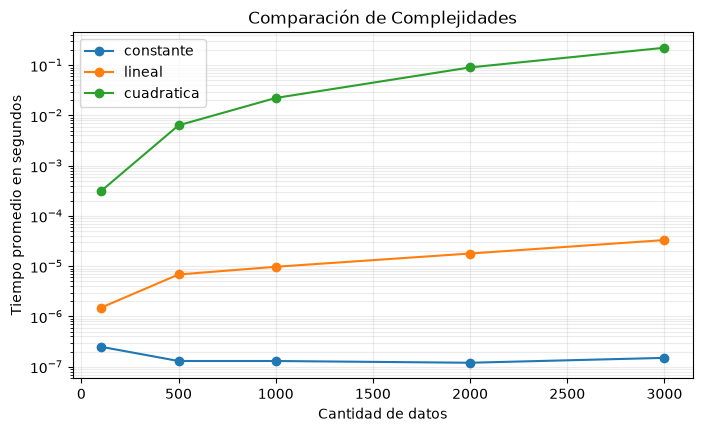

In [95]:
tamanos = [100, 500, 1000, 2000, 3000]
ys_constante = []
ys_lineal = []
ys_cuadratica = []

for tamano in tamanos:
    datos = generar_datos(tamano)
    t1 = medir_tiempo_base(lambda: ejemplo_constante(datos))
    ys_constante.append(t1)

    t2 = medir_tiempo_base(lambda: ejemplo_lineal(datos,-1))
    ys_lineal.append(t2)

    t3 = medir_tiempo_base(lambda: ejemplo_cuadratico(datos))
    ys_cuadratica.append(t3)
resultados = []

plt.figure(figsize=(8, 4.5))
plt.plot(tamanos, ys_constante, marker='o', label='constante')
plt.plot(tamanos, ys_lineal, marker='o', label='lineal')
plt.plot(tamanos, ys_cuadratica, marker='o', label='cuadratica')
plt.yscale('log') 

plt.xlabel('Cantidad de datos')
plt.ylabel('Tiempo promedio en segundos')
plt.title('Comparación de Complejidades')
plt.legend()
plt.grid(True, which='both', alpha=0.25)
plt.show()

## 11. Ejercicio para completar

Cambia los tamaños y repeticiones. Observa si tu conclusión se mantiene.

In [92]:
# Puedes modificar estos valores.
tamanos_ejercicio = [2_000, 20_000, 80_000]
repeticiones_ejercicio = 6

resultados_ejercicio = comparar_busquedas_por_tamano(
    tamanos_ejercicio,
    repeticiones=repeticiones_ejercicio,
)

for fila in resultados_ejercicio:
    print(fila)

{'tamano': 2000, 'tiempo_lista': 9.283333080626713e-06, 'tiempo_conjunto': 3.9999940781854093e-07}
{'tamano': 20000, 'tiempo_lista': 0.00013006666722503724, 'tiempo_conjunto': 2.0000000707417107e-07}
{'tamano': 80000, 'tiempo_lista': 0.0003953666670592308, 'tiempo_conjunto': 2.1666740697886175e-07}


Escribe aquí tu conclusión:

- Estructura que usaría para muchas búsquedas: Conjuntos 
- Razón: porque su complejidad es constante
- Sacrificio posible: convertir los datos a conjuntos, poruqe pueden ser un arreglo o alguna otra estructuta, y tambien se pierden ciertos datos, la frecuencia por ejemplo

## 12. Actividad de proyecto / GitHub

Elige o crea uno de estos issues:

- `[DOC] Escribir guía de estilo`
- `[DOC] Documentar flujo básico de GitHub`
- `[TEST] Crear primera prueba de ejemplo`
- `[PROY] Definir estructura inicial de src/`

Flujo esperado:

`Issue → Branch → Commit → Pull Request → Review → Merge`

No trabajes directamente sobre `main`.

## 13. Reflexión final

Responde:

1. ¿Cuál fue más rápido: `list` o `set` para pertenencia?
    - Set 
2. ¿La diferencia crece con el tamaño?
    - Si y mucho
3. ¿Qué estructura usarías si necesitas muchas búsquedas?
    - Sets
4. ¿Qué estructura usarías si necesitas contar frecuencias?
    - Counter
5. ¿Qué sacrificios tiene usar un `set` en lugar de una `list`?
    - Pierdes informacion sobre el orden y la frecuencia 
6. ¿Qué aprendiste al medir en lugar de solo razonar?
    - Aprendi sobre los limites que tienen las computadoras al ejecutar el codigo con muchos datos 

## 14. Reto opcional

La búsqueda en `set` es rápida, pero construir el `set` también cuesta. Mide el costo total de:

1. Construir el conjunto.
2. Hacer muchas búsquedas.

Pregunta: ¿a partir de cuántas búsquedas empieza a convenir construir el conjunto?
- Con mas de una ya parece conveniente 

In [99]:
def tiempo_consultas_lista(datos, consultas):
    inicio = time.perf_counter()
    for consulta in consultas:
        consulta in datos
    return time.perf_counter() - inicio


def tiempo_construir_set_y_consultar(datos, consultas):
    inicio = time.perf_counter()
    conjunto = set(datos)
    for consulta in consultas:
        consulta in conjunto
    return time.perf_counter() - inicio


datos_reto = generar_datos(30_000)

for cantidad in [1, 2, 10, 50, 100, 500, 1_000]:
    consultas = [-1 - i for i in range(cantidad)]
    t_lista = tiempo_consultas_lista(datos_reto, consultas)
    t_set_total = tiempo_construir_set_y_consultar(datos_reto, consultas)
    print(f'{cantidad:>5,} consultas | lista: {t_lista:.5f}s | set total: {t_set_total:.5f}s')

    1 consultas | lista: 0.00019s | set total: 0.00041s
    2 consultas | lista: 0.00033s | set total: 0.00042s
   10 consultas | lista: 0.00180s | set total: 0.00050s
   50 consultas | lista: 0.00833s | set total: 0.00038s
  100 consultas | lista: 0.01658s | set total: 0.00035s
  500 consultas | lista: 0.07407s | set total: 0.00035s
1,000 consultas | lista: 0.14542s | set total: 0.00041s
